In [1]:
import os
import json
import time
import argparse
from typing import Tuple, Optional
import re

import numpy as np
from scipy.optimize import minimize

#few and SEF imports
from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux
from few.utils.geodesic import get_fundamental_frequencies
from scipy.interpolate import CubicSpline
from scipy.integrate import cumulative_trapezoid
from few.utils.constants import MTSUN_SI

from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from stableemrifisher.utils import generate_PSD, inner_product
from stableemrifisher.fisher import StableEMRIFisher
import matplotlib.pyplot as plt

from config_paris import Config, ObjectiveTracker
from misc import *
from misc import fishinv

try:
    import cupy as cp
    xp=cp
except:
    xp=np
    print("CuPy not found, using NumPy instead. For GPU acceleration, please install CuPy.")

from inference import  prepare_true_waveform

startup


[INFO] Finished loading modules and building ResponseWrapper
[INFO] Finished generating true waveform
shape check - waveform_true: (3, 3155814) PSD_funcs: (3, 1577907)
[TRUE] SNR: 56.117063
[TRUE] SNR - Channel 0: 29.274638
[TRUE] SNR - Channel 1: 24.652424
[TRUE] SNR - Channel 2: 41.041178
[INFO] Frequency resolution delta_f: 3.168755e-08 Hz, Number of frequency bins: 1577908
freq_max: 0.050000 Hz and Freq_min: 0.000000 Hz


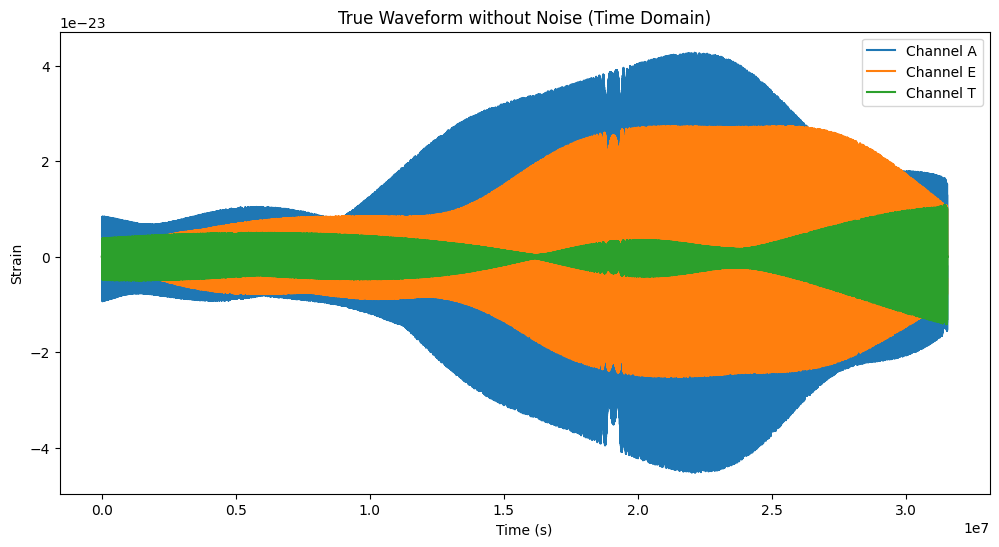

[INFO] Added noise to true waveform FFT

shape of waveform_true_fft after noise addition: (3, 1577907)


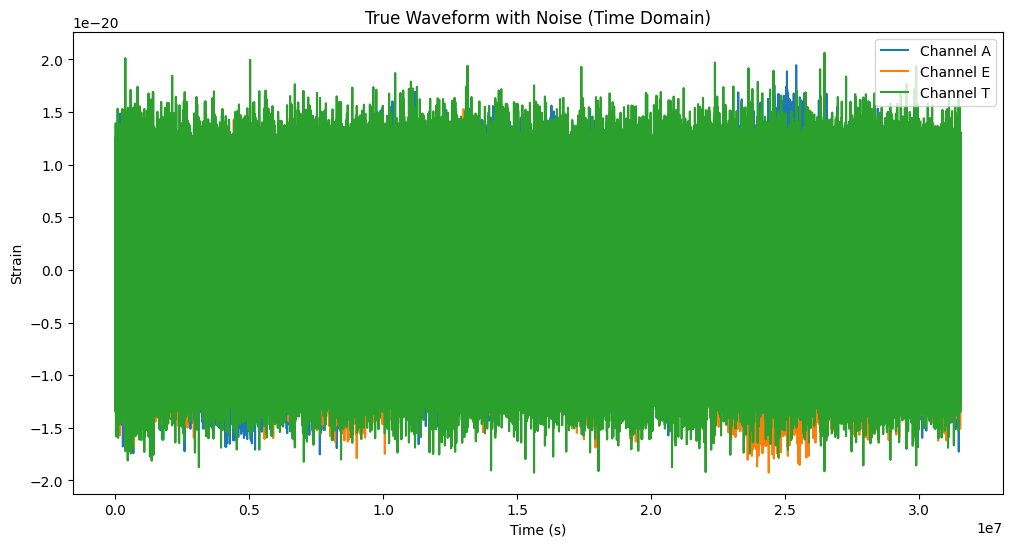

Length of PSD: 1577907


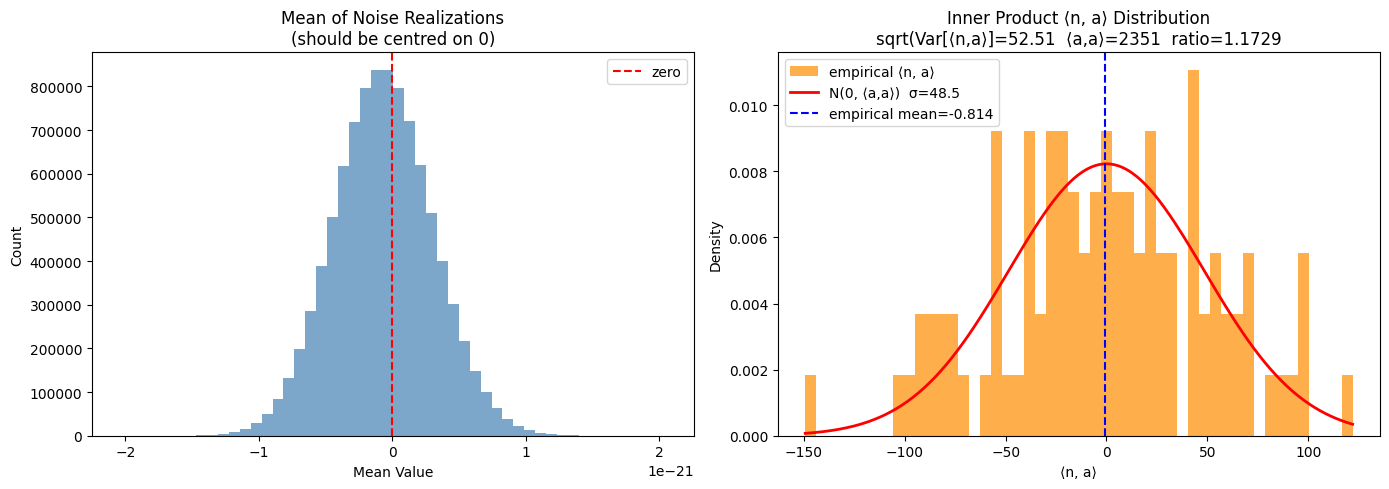

  Noise model consistency check
  Backend                : CuPy (GPU)
  Realizations           : 100
  N time samples         : 3155812  |  PSD bins passed: 1577906
  N (template samples)   : 3155814  →  aligned to 3155812
  Max |mean noise|       : 2.0551e-21  (expect ≈ 0)
  E[⟨n, a⟩]             : -8.1413e-01           (expect ≈ 0)
  Var[⟨n, a⟩]           : 2757.75
  ⟨a, a⟩                : 2351.33
  Ratio Var/⟨a,a⟩       : 1.172850          (expect ≈ 1.0)
Noise consistency check results: {'mean_noise': array([[-8.24851126e-22,  4.33131588e-22, -1.60594713e-22, ...,
        -2.14864290e-22,  6.75644221e-23,  9.17909493e-23],
       [-4.42571907e-22,  4.43612922e-24,  1.26346062e-22, ...,
        -2.83471365e-22, -1.41343948e-22,  3.19965441e-22],
       [-2.28135965e-22,  2.24084932e-22, -7.26844260e-23, ...,
        -8.38119872e-23, -6.52348843e-22,  4.92708503e-22]],
      shape=(3, 3155812)), 'inner_products': array([  56.50327042,  -54.86381078,   25.23093475,  -55.9357626 ,
    

{'m1': np.float64(1000000.0),
 'm2': np.float64(10.0),
 'a': np.float64(0.9),
 'p0': np.float64(7.5),
 'e0': np.float64(0.5),
 'Y0': np.float64(1.0),
 'dist': np.float64(5.0),
 'qS': np.float64(0.7853981633974483),
 'phiS': np.float64(1.0),
 'qK': np.float64(1.0),
 'phiK': np.float64(1.0471975511965976),
 'Phi_phi0': np.float64(0.9),
 'Phi_theta0': np.float64(0.5),
 'Phi_r0': np.float64(0.4),
 'dt': 10,
 'T': 1.0,
 'chi2': 0.0,
 'dev_1': 0.0,
 'dev_2': 0.0,
 'waveform_response': <fastlisaresponse.response.ResponseWrapper at 0x1552bc59ac00>,
 'PSD_funcs': array([[6.81763434e-35, 1.70440862e-35, 7.57514968e-36, ...,
         1.61311193e-40, 1.61310358e-40, 1.61309523e-40],
        [6.81763434e-35, 1.70440862e-35, 7.57514968e-36, ...,
         1.61311193e-40, 1.61310358e-40, 1.61309523e-40],
        [2.65994853e-56, 1.06395802e-55, 2.39388950e-55, ...,
         5.36070468e-40, 5.36068302e-40, 5.36066135e-40]],
       shape=(3, 1577907)),
 'waveform_true_fft': array([[-6.25689817e-15-2.560

In [2]:
seed= 42   
param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
params_name = ["m1","m2","a","p0","e0","xI0","dist","qS","phiS","qK","phiK",
                         "Phi_phi0","Phi_theta0","Phi_r0"]      

params = np.array([1e6,1e1,0.9, 7.5,  5.00000000e-01,  1.00000000e+00,
          5.0,  np.pi/4,  1.0, 1,  np.pi/3,  9.00000000e-01, 5.00000000e-01,  4.00000000e-01])

signal_param = {"m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 5.0,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}
signal_param_array = np.array(list(signal_param.values()))
dt = 10  #Time step for waveform generation; default 0.1s
T= 1.0

chi2 = 0.0 
dev_1 = 0.0
dev_2 = 0.0

emri_kwargs = {"T": T, "dt": dt,'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}
add_kwargs = {'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}

# if target_func in ('optimal_snr', 'optimal_snr_phase_max','time_max'):
        
ctx = prepare_true_waveform(signal_param_array, emri_kwargs, add_kwargs,add_noise=True, use_gpu=True,seed=seed)

snr_2 = inner_prod(ctx['waveform_true_fft_without_noise'], ctx['waveform_true_fft_without_noise'], ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
ctx

# Overlap with Noise and With True Signal Without Noise

In [6]:
noise_f =  ctx['noise']
Respsone = ctx['waveform_response']


In [11]:
use_gpu = True
channels = [A1TDISens, E1TDISens, T1TDISens]
noise_kwargs = [{"sens_fn": ch} for ch in channels]

sef = StableEMRIFisher(waveform_class=SuperKludgeWaveform,
                       waveform_class_kwargs = dict(sum_kwargs=dict(pad_output=False, odd_len=True)),
                       waveform_generator = GenerateEMRIWaveform,
                       waveform_generator_kwargs= dict(return_list=False),
                       ResponseWrapper=ResponseWrapper,
                       ResponseWrapper_kwargs = dict(Tobs=ctx['T'],
                                                    t0=10000.0,
                                                    dt=ctx['dt'],
                                                    index_lambda=8,
                                                    index_beta=7,
                                                    flip_hx=True,
                                                    is_ecliptic_latitude=False,
                                                    remove_garbage="zero",
                                                    orbits=EqualArmlengthOrbits(use_gpu=use_gpu),
                                                    force_backend = "cuda12x" if use_gpu else "cpu",
                                                    order=20,
                                                    tdi="2nd generation",
                                                    tdi_chan="AET"),
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs=noise_kwargs,
                       channels=channels,
                       T = ctx['T'], dt = ctx['dt'],
                       stability_plot = False,
                       der_order = 6, Ndelta = 12,
                       plunge_check=True, return_derivatives=False
                       )
emri_kwargs = {"T":ctx['T'], "dt":ctx['dt']}



waveform shape: (3, 3155814)
wave ndim: 2
Computing SNR for parameters: (999946.0152291667, 9.999519502525063, 0.8999722828661775, 7.500180664516796, 0.5000138337896617, np.float64(1.0), np.float64(5.0), 0.7852559788367258, 1.0129022856696843, np.float64(1.0), np.float64(1.0471975511965976), 1.0763850352976, np.float64(0.5), 0.38346661248402214, 0.0, True, False, False, False, 0, 0)
SNR:  55.002828610250575
Body is not plunging, Fisher should be stable.
waveform shape: (3, 3155814)
wave ndim: 2
Computing SNR for parameters: (999946.0152291667, 9.999519502525063, 0.8999722828661775, 7.500180664516796, 0.5000138337896617, np.float64(1.0), np.float64(5.0), 0.7852559788367258, 1.0129022856696843, np.float64(1.0), np.float64(1.0471975511965976), 1.0763850352976, np.float64(0.5), 0.38346661248402214, 0.0, True, False, False, False, 0, 0)
Waveform Generated. SNR: 55.002828610250575
calculating stable deltas...
Gamma_ii for m1: 197779.92309836217
Gamma_ii for m1: 197779.97146226087
Gamma_ii fo

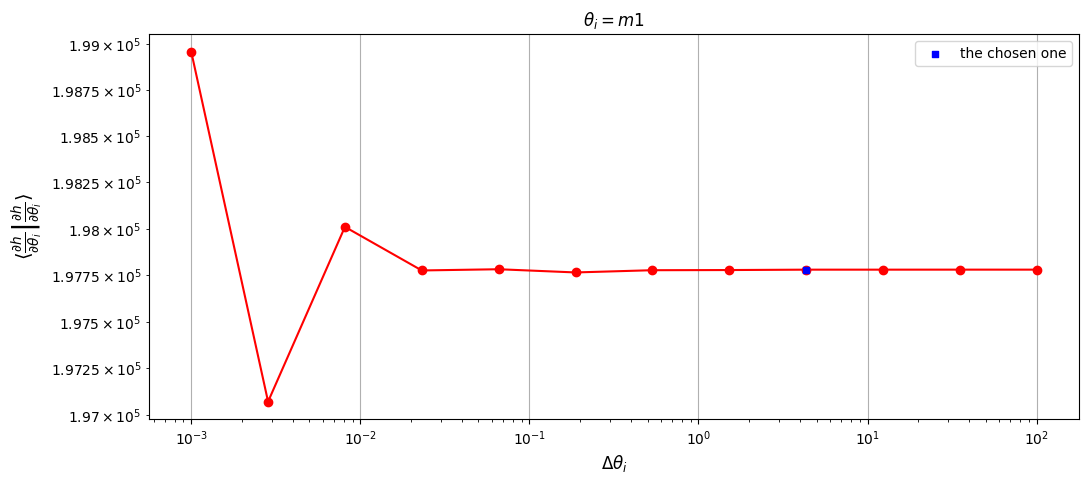

Gamma_ii for m2: 117431883696578.75
Gamma_ii for m2: 117432143710807.16
Gamma_ii for m2: 117431254075332.23
Gamma_ii for m2: 117431758713601.88
Gamma_ii for m2: 117429099289353.55
Gamma_ii for m2: 117416645742027.14
Gamma_ii for m2: 117396272030258.42
Gamma_ii for m2: 117437079832762.7
Gamma_ii for m2: 117421457630810.78
Gamma_ii for m2: 117994052485419.64
Gamma_ii for m2: 115707102909674.05
Gamma_ii for m2: 120322090591058.2
[np.float64(2.214165731714571e-06), np.float64(7.575798129100905e-06), np.float64(4.297289550702895e-06), np.float64(2.2647063329465866e-05), np.float64(0.00010606287760738451), np.float64(0.00017354649697451643), np.float64(0.00034748652267575076), np.float64(0.0001330438428131273), np.float64(0.004852743359074087), np.float64(0.019764988650099426), np.float64(0.03835528171688135)]
0


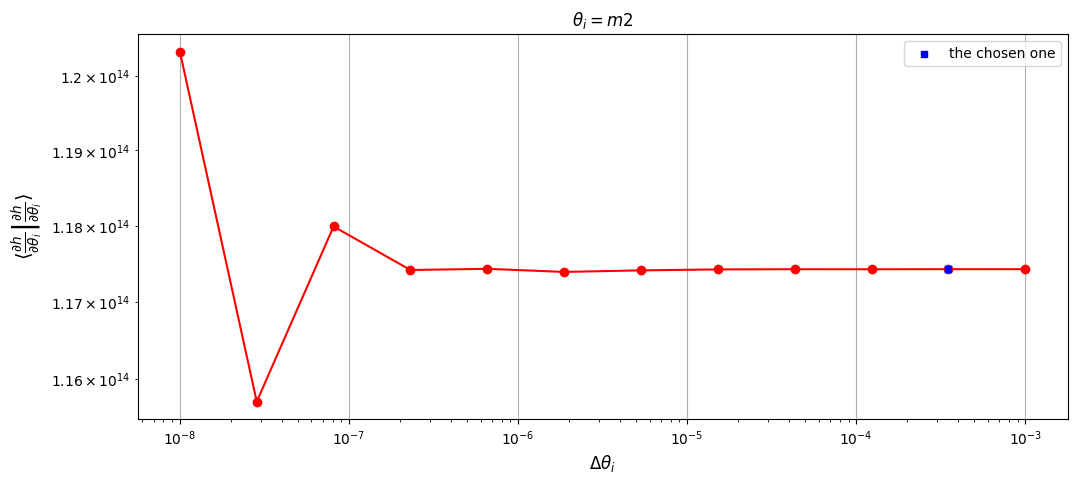

Gamma_ii for a: 7670599724137151.0
Gamma_ii for a: 7670615901918383.0
Gamma_ii for a: 7670708568089250.0
Gamma_ii for a: 7670487482499324.0
Gamma_ii for a: 7671048614000005.0
Gamma_ii for a: 7668884682469153.0
Gamma_ii for a: 7675702449048732.0
Gamma_ii for a: 7674675778350300.0
Gamma_ii for a: 7650253503324866.0
Gamma_ii for a: 7753309743142722.0
Gamma_ii for a: 7366925077955116.0
Gamma_ii for a: 7917179368426999.0
[np.float64(2.1090589646072642e-06), np.float64(1.2080522945754784e-05), np.float64(2.882288647630545e-05), np.float64(7.314925623817715e-05), np.float64(0.00028217030512907364), np.float64(0.0008882270547660354), np.float64(0.00013377382029976603), np.float64(0.003192348464638442), np.float64(0.01329190284304097), np.float64(0.05244856722431297), np.float64(0.06950130404601515)]
0


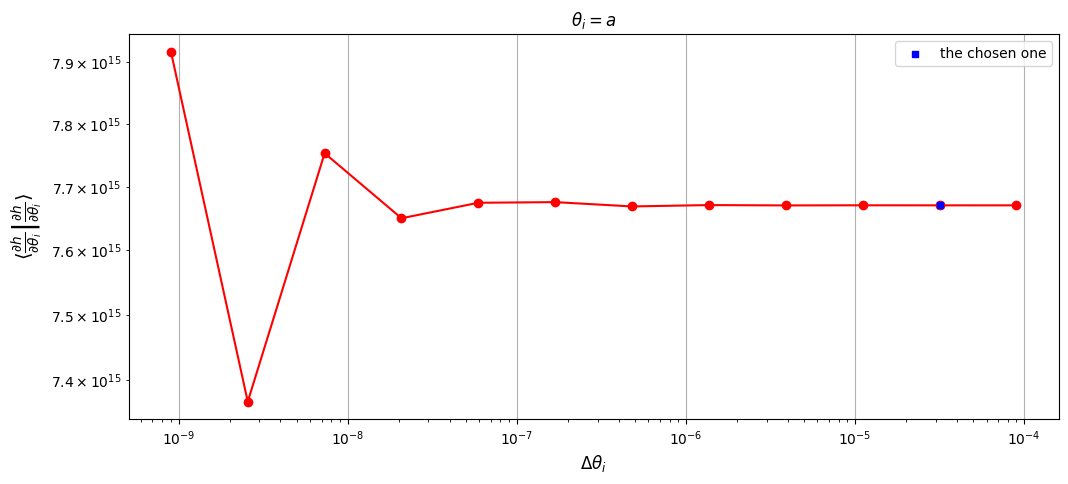

Gamma_ii for p0: 9322013007252320.0
Gamma_ii for p0: 9322013254751312.0
Gamma_ii for p0: 9322011285323108.0
Gamma_ii for p0: 9321991967604698.0
Gamma_ii for p0: 9322011830623598.0
Gamma_ii for p0: 9321908751324124.0
Gamma_ii for p0: 9322057904203374.0
Gamma_ii for p0: 9321918914650428.0
Gamma_ii for p0: 9327572310973788.0
Gamma_ii for p0: 9317810277044824.0
Gamma_ii for p0: 9295561925159680.0
Gamma_ii for p0: 9263725624277456.0
[np.float64(2.6549950663699485e-08), np.float64(2.112664470918132e-07), np.float64(2.0722736596568557e-06), np.float64(2.1307652533488857e-06), np.float64(1.1057746028607947e-05), np.float64(1.5999994934889433e-05), np.float64(1.4909972315631552e-05), np.float64(0.000606095148328021), np.float64(0.0010476746830758677), np.float64(0.0023934380798352668), np.float64(0.0034366627611239447)]
0


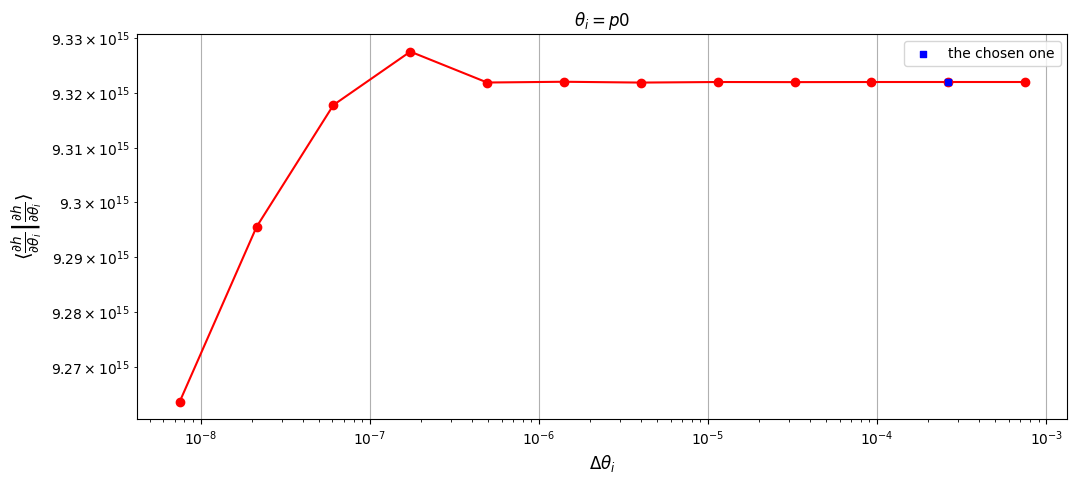

Gamma_ii for e0: 7.514334935479997e+16
Gamma_ii for e0: 7.514338862253123e+16
Gamma_ii for e0: 7.5143250347585e+16
Gamma_ii for e0: 7.514425223204645e+16
Gamma_ii for e0: 7.514756577970326e+16
Gamma_ii for e0: 7.514287694338374e+16
Gamma_ii for e0: 7.511726369297907e+16
Gamma_ii for e0: 7.522885074469366e+16
Gamma_ii for e0: 7.513906888775227e+16
Gamma_ii for e0: 7.559701296171546e+16
Gamma_ii for e0: 7.530355690123458e+16
Gamma_ii for e0: 8.062099906858853e+16
[np.float64(5.225706743310993e-07), np.float64(1.8401512524463747e-06), np.float64(1.3332815640538514e-05), np.float64(4.409387878949716e-05), np.float64(6.239894598463131e-05), np.float64(0.00034097688261594615), np.float64(0.0014833012947823466), np.float64(0.00119487582519174), np.float64(0.0060577006421550054), np.float64(0.00389697475865272), np.float64(0.06595604406775119)]
0


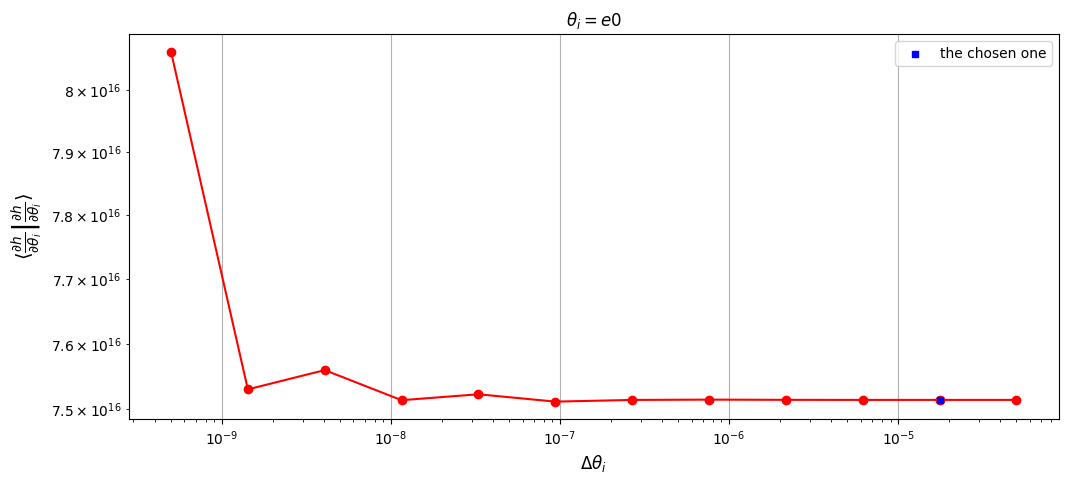

Gamma_ii for qS: 6354979.545168449
Gamma_ii for qS: 5319646.531117481
Gamma_ii for qS: 4863832.053927788
Gamma_ii for qS: 5941957.449520122
Gamma_ii for qS: 5150936.391327201
Gamma_ii for qS: 1258681.1281893102
Gamma_ii for qS: 2479903.923786496
Gamma_ii for qS: 76303678.50698629
Gamma_ii for qS: 856444655.9960899
Gamma_ii for qS: 7702041180.056875
Gamma_ii for qS: 64669662576.99213
Gamma_ii for qS: 530869938368.5006
[np.float64(0.19462439994739253), np.float64(0.09371509380583991), np.float64(0.18144279974260083), np.float64(0.1535683996262871), np.float64(3.092328291866216), np.float64(0.4924476242339803), np.float64(0.9674995495327341), np.float64(0.910906469002085), np.float64(0.8888028983519709), np.float64(0.880901788054217), np.float64(0.8781817204120871)]
1
minimum relative error is greater than 1% for qS. Fisher may be unstable!


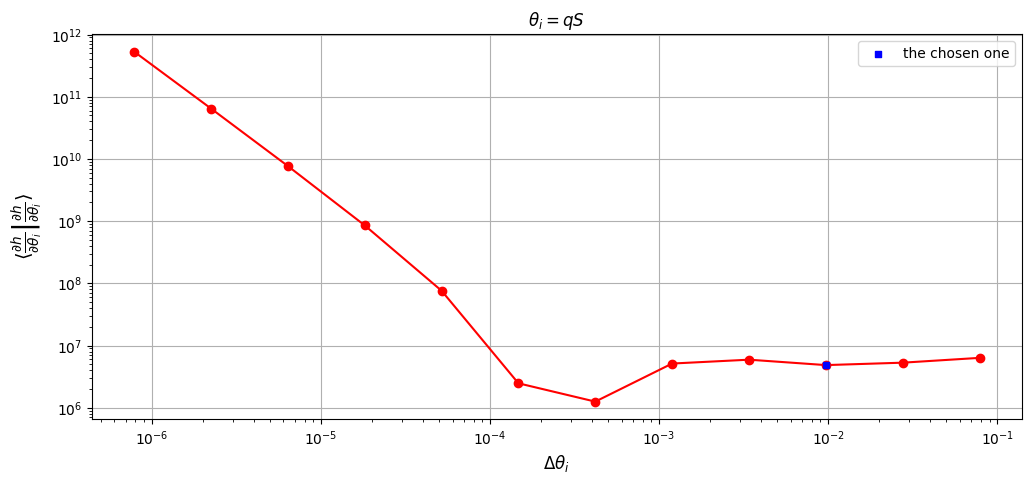

Gamma_ii for phiS: 17190677.131804124
Gamma_ii for phiS: 24114574.057518527
Gamma_ii for phiS: 24271310.510926068
Gamma_ii for phiS: 25333012.90608227
Gamma_ii for phiS: 27871333.297173988
Gamma_ii for phiS: 35557110.44857474
Gamma_ii for phiS: 62664073.55955718
Gamma_ii for phiS: 182023303.4815064
Gamma_ii for phiS: 864590488.9040096
Gamma_ii for phiS: 5581347053.521241
Gamma_ii for phiS: 1459958981.9258816
Gamma_ii for phiS: 23617014.1310362
[np.float64(0.2871249937568624), np.float64(0.00645768399431847), np.float64(0.04190983516616352), np.float64(0.09107280100407296), np.float64(0.21615302971585598), np.float64(0.43257582169820874), np.float64(0.6557359834647554), np.float64(0.7894687649036637), np.float64(0.8450928636737355), np.float64(2.8229478516983377), np.float64(60.81810172215135)]
1


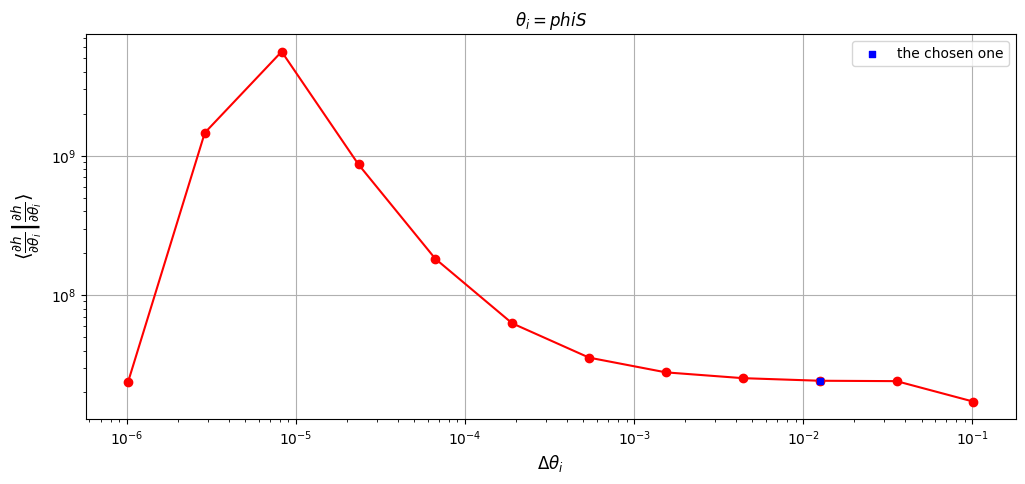

stable deltas: {'m1': 4.3285275938973085, 'm2': 0.00035110230223388993, 'a': 3.1599752406224497e-05, 'p0': 0.0002633457235437153, 'e0': 1.7556444401954773e-05, 'qS': 0.009681002731362456, 'phiS': 0.01248753280261287, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 50.090250968933105 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 3.4473986625671387 seconds


In [12]:
x_best_fit_1PA = [999946.0152291667, 9.999519502525063, 0.8999722828661775, 7.500180664516796,
                   0.5000138337896617, 0.7852559788367258, 1.0129022856696843, 1.0763850352976, 0.38346661248402214]

add_kwargs_1PA = {'chi2': 0.0, 'evolve_1PA': True, 'evolve_primary': False,
                      'evolve_2PA': False, 'deviation_included': False,
                      'dev_1': 0, 'dev_2': 0}

m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = x_best_fit_1PA
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs_1PA['chi2'],add_kwargs_1PA['evolve_1PA'],add_kwargs_1PA['evolve_primary'],
                    add_kwargs_1PA['evolve_2PA'], add_kwargs_1PA['deviation_included'],add_kwargs_1PA['dev_1'],add_kwargs_1PA['dev_2']]


param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
dim = len(param_names_to_infer)
param_names = param_names_to_infer
SNR = sef.SNRcalc_SEF(*wave_params,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict = {
    'm1': wave_params[0],
    'm2': wave_params[1],
    'a': wave_params[2],
    'p0': wave_params[3],
    'e0': wave_params[4],
    'xI0': wave_params[5],
    'dist': wave_params[6],
    'qS': wave_params[7],
    'phiS': wave_params[8],
    'qK': wave_params[9],
    'phiK': wave_params[10],
    'Phi_phi0': wave_params[11],
    'Phi_theta0': wave_params[12],
    'Phi_r0': wave_params[13]}

Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_kwargs_1PA,
            live_dangerously = False, stability_plot = True,der_order = 6, Ndelta = 12,return_derivatives = False)

Covariance_fit_1PA = fishinv(m1, Fisher, index_of_M=0)


waveform shape: (3, 3155814)
wave ndim: 2


Computing SNR for parameters: (1000117.1746453623, 10.000746537405398, 0.9000818185010706, 7.499523528259836, 0.49998409810055455, np.float64(1.0), np.float64(5.0), 0.781083551558284, 1.0107113878780554, np.float64(1.0), np.float64(1.0471975511965976), 1.074751977593931, np.float64(0.5), 0.38365434296900686, 0.0, False, False, False, True, 0, 0)
SNR:  54.93708825533405
Body is not plunging, Fisher should be stable.
waveform shape: (3, 3155814)
wave ndim: 2
Computing SNR for parameters: (1000117.1746453623, 10.000746537405398, 0.9000818185010706, 7.499523528259836, 0.49998409810055455, np.float64(1.0), np.float64(5.0), 0.781083551558284, 1.0107113878780554, np.float64(1.0), np.float64(1.0471975511965976), 1.074751977593931, np.float64(0.5), 0.38365434296900686, 0, False, False, False, True, 2.4076903823412796, -2.5709170953033844)
Waveform Generated. SNR: 459.9575122787029
calculating stable deltas...
Gamma_ii for m1: 354040.87804028916
Gamma_ii for m1: 354040.924689976
Gamma_ii for m1:

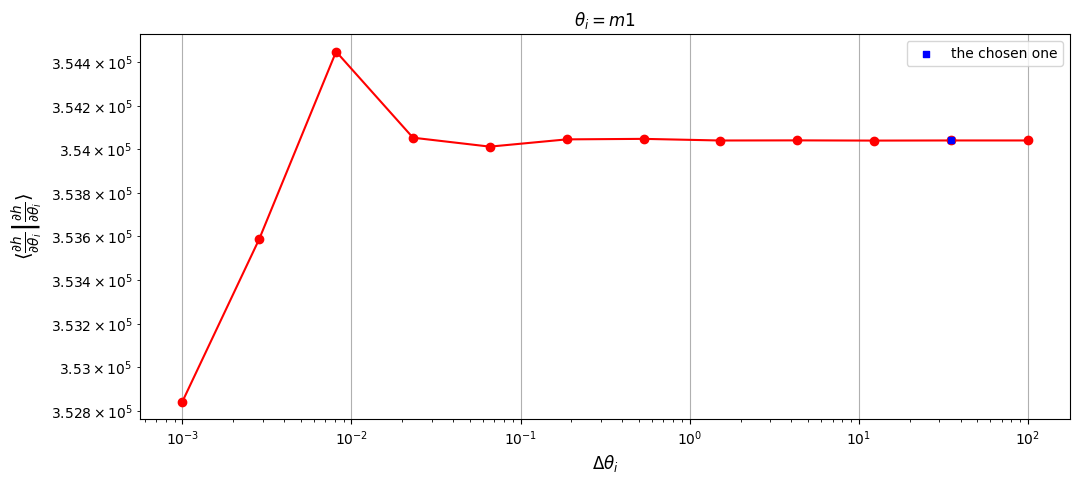

Gamma_ii for m2: 222339521128343.12
Gamma_ii for m2: 222339493324822.8
Gamma_ii for m2: 222338590799943.75
Gamma_ii for m2: 222337980590136.6
Gamma_ii for m2: 222332590874143.47
Gamma_ii for m2: 222358321476014.97
Gamma_ii for m2: 222331291265877.62
Gamma_ii for m2: 222268570419043.84
Gamma_ii for m2: 222371620416118.7
Gamma_ii for m2: 223363985676929.6
Gamma_ii for m2: 221208663504212.8
Gamma_ii for m2: 219347406002118.75
[np.float64(1.2504985010414213e-07), np.float64(4.059236301783416e-06), np.float64(2.7445144798770394e-06), np.float64(2.4241682121070474e-05), np.float64(0.00011571683803286611), np.float64(0.00012157627468199849), np.float64(0.00028218495631448647), np.float64(0.0004634134377489752), np.float64(0.004442816767454396), np.float64(0.009743389515464137), np.float64(0.00848543201863114)]
0


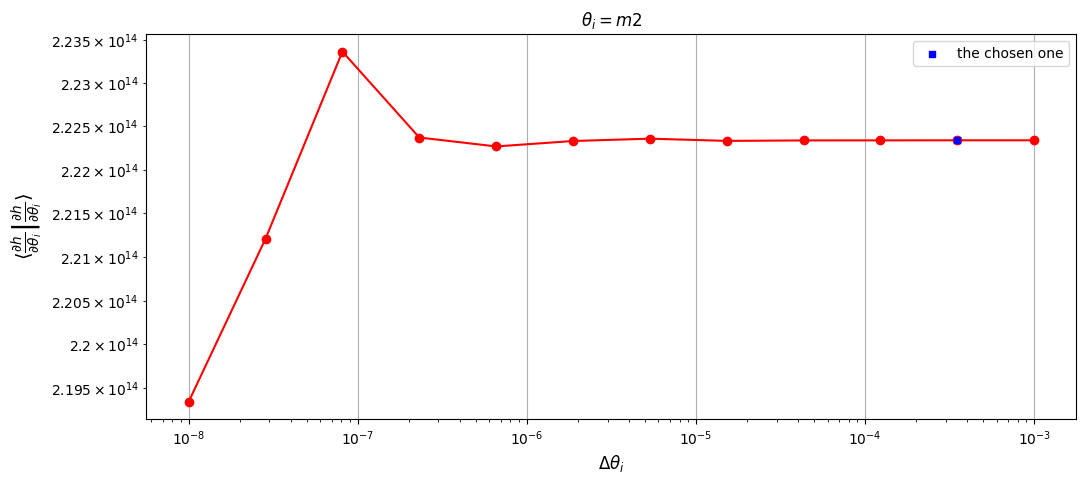

Gamma_ii for a: 2.0830115878685532e+16
Gamma_ii for a: 2.0830124222983116e+16
Gamma_ii for a: 2.0830099912500564e+16
Gamma_ii for a: 2.082991316418636e+16
Gamma_ii for a: 2.082972496262379e+16
Gamma_ii for a: 2.0831582626338996e+16
Gamma_ii for a: 2.083200979333858e+16
Gamma_ii for a: 2.080765699843459e+16
Gamma_ii for a: 2.091231017434792e+16
Gamma_ii for a: 2.0681294468235404e+16
Gamma_ii for a: 2.0143729064736428e+16
Gamma_ii for a: 1.984471960124343e+16
[np.float64(4.0058798952304086e-07), np.float64(1.1670842988809088e-06), np.float64(8.965390913154802e-06), np.float64(9.035239923028412e-06), np.float64(8.91753520855977e-05), np.float64(2.050531868128223e-05), np.float64(0.0011703766025083996), np.float64(0.005004381392625899), np.float64(0.011170273043949701), np.float64(0.02668648896991158), np.float64(0.015067457212862843)]
0


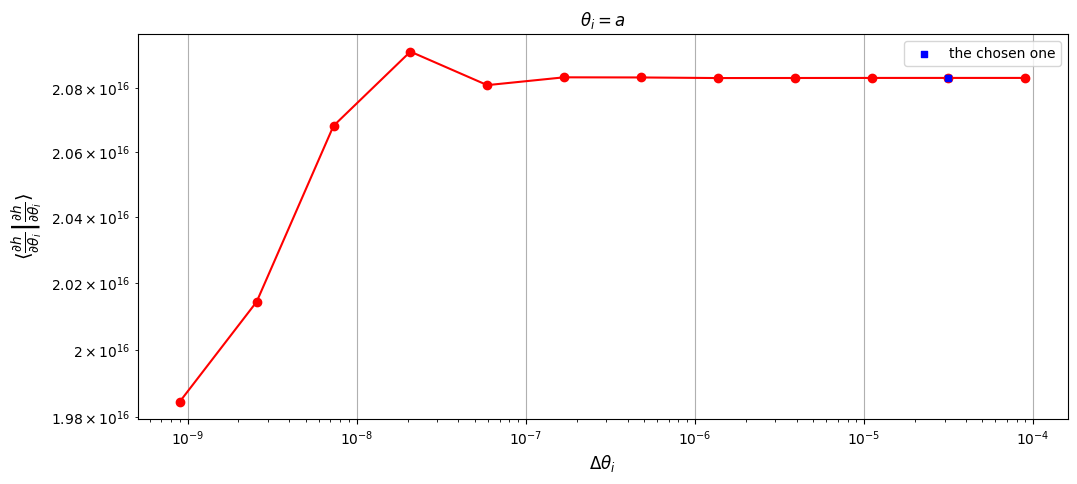

Gamma_ii for p0: 1.7708971918765052e+16
Gamma_ii for p0: 1.770896657343627e+16
Gamma_ii for p0: 1.770899029377695e+16
Gamma_ii for p0: 1.7708994203822342e+16
Gamma_ii for p0: 1.7708940105369886e+16
Gamma_ii for p0: 1.7708791144955494e+16
Gamma_ii for p0: 1.7708969730981522e+16
Gamma_ii for p0: 1.7707391486256796e+16
Gamma_ii for p0: 1.7707180024431652e+16
Gamma_ii for p0: 1.7702363688875856e+16
Gamma_ii for p0: 1.773721639726796e+16
Gamma_ii for p0: 1.7662363307702388e+16
[np.float64(3.018430668912142e-07), np.float64(1.3394518990919248e-06), np.float64(2.2079432332503946e-07), np.float64(3.054866758490855e-06), np.float64(8.411664758632194e-06), np.float64(1.0084495526330194e-05), np.float64(8.912914846610355e-05), np.float64(1.1942151424011813e-05), np.float64(0.0002720730203290637), np.float64(0.001964948028568469), np.float64(0.004237999652794441)]
2


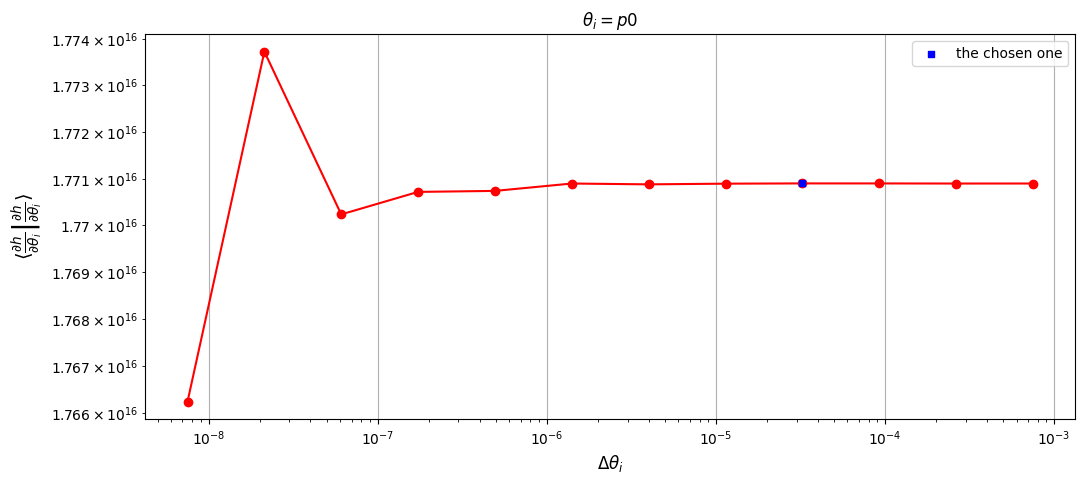

Gamma_ii for e0: 1.2878322782767392e+17
Gamma_ii for e0: 1.2878307575459496e+17
Gamma_ii for e0: 1.287835437026092e+17
Gamma_ii for e0: 1.287834874535874e+17
Gamma_ii for e0: 1.2878546305287326e+17
Gamma_ii for e0: 1.287829807647864e+17
Gamma_ii for e0: 1.2875988913413358e+17
Gamma_ii for e0: 1.2876137681817522e+17
Gamma_ii for e0: 1.2909312882014168e+17
Gamma_ii for e0: 1.2897514525854693e+17
Gamma_ii for e0: 1.2853054623192968e+17
Gamma_ii for e0: 1.310768028373663e+17
[np.float64(1.1808467694139076e-06), np.float64(3.633601008220425e-06), np.float64(4.367720033072697e-07), np.float64(1.534023514021075e-05), np.float64(1.927496996981096e-05), np.float64(0.00017933869629819778), np.float64(1.1553806571459456e-05), np.float64(0.00256986568532765), np.float64(0.0009147775050630033), np.float64(0.003459092329810704), np.float64(0.019425684410352112)]
2


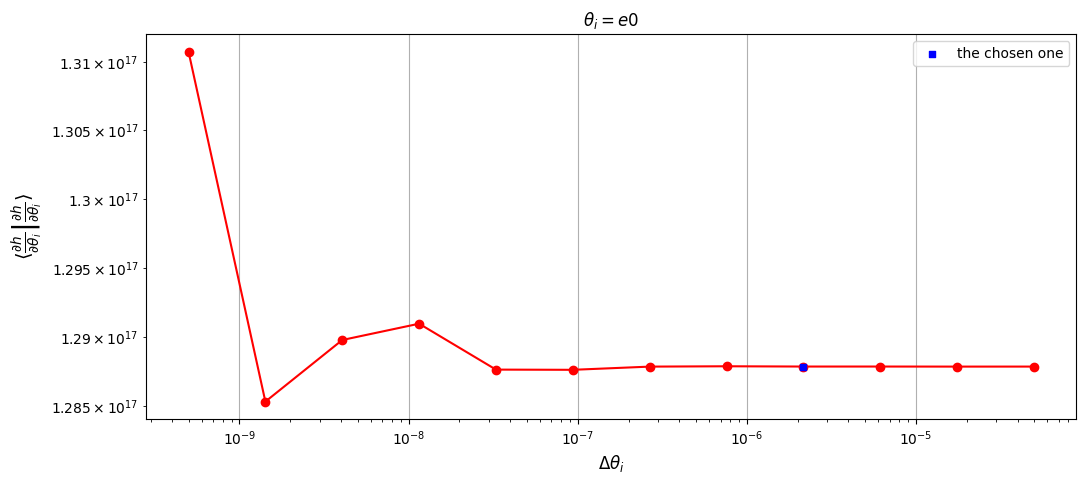

Gamma_ii for qS: 7495416.832822719
Gamma_ii for qS: 5363474.84978171
Gamma_ii for qS: 5385778.547552231
Gamma_ii for qS: 5307909.365439638
Gamma_ii for qS: 3449704.25408043
Gamma_ii for qS: 7088251.277648884
Gamma_ii for qS: 6277809.003634826
Gamma_ii for qS: 6276410.434178849
Gamma_ii for qS: 6315259.959704361
Gamma_ii for qS: 6315168.574611128
Gamma_ii for qS: 6440615.246708158
Gamma_ii for qS: 6401981.209217365
[np.float64(0.39749267830122814), np.float64(0.004141220730410053), np.float64(0.014670405380244006), np.float64(0.5386563526891495), np.float64(0.5133208292208471), np.float64(0.12909635727127328), np.float64(0.00022282950910308116), np.float64(0.006151690630852646), np.float64(1.4470729031686069e-05), np.float64(0.019477436128659716), np.float64(0.006034700232354551)]
8


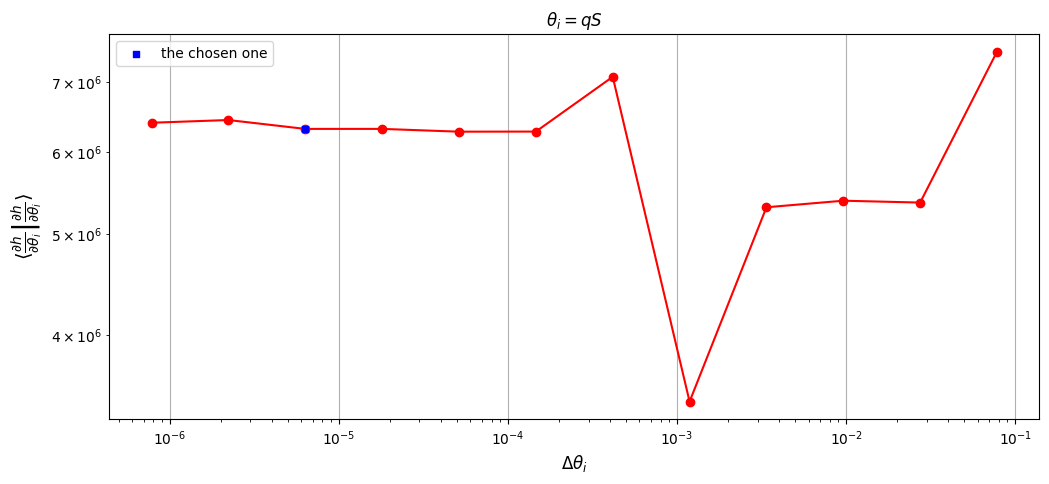

Gamma_ii for phiS: 35730665.007137395
Gamma_ii for phiS: 41831891.30947079
Gamma_ii for phiS: 42023729.11139802
Gamma_ii for phiS: 41048415.47994338
Gamma_ii for phiS: 41285839.19667407
Gamma_ii for phiS: 41285999.399577595
Gamma_ii for phiS: 41276092.190243855
Gamma_ii for phiS: 41280544.31599602
Gamma_ii for phiS: 41230873.60033894
Gamma_ii for phiS: 41374035.06514426
Gamma_ii for phiS: 41645954.58843497
Gamma_ii for phiS: 41900601.00794777
[np.float64(0.14585107465490252), np.float64(0.004564987591146437), np.float64(0.023760079897144532), np.float64(0.005750730065087741), np.float64(3.880320347184819e-06), np.float64(0.00024002294810461427), np.float64(0.00010785046142041143), np.float64(0.001204697143663466), np.float64(0.003460176523268984), np.float64(0.006529314214980687), np.float64(0.006077393005997674)]
4


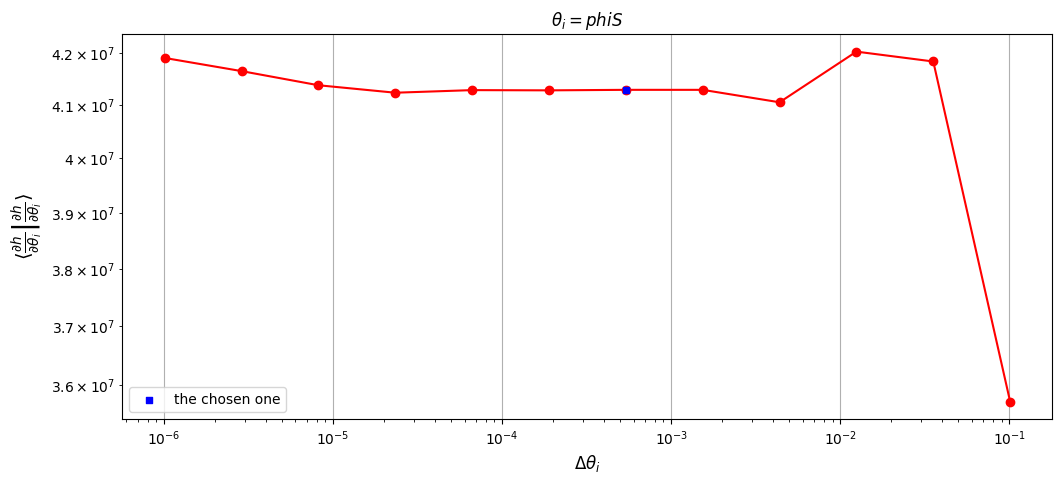

stable deltas: {'m1': 35.11603156861386, 'm2': 0.00035114538578118437, 'a': 3.160359841238289e-05, 'p0': 3.2463647075702594e-05, 'e0': 2.1643118050149143e-06, 'qS': 6.335609500916308e-06, 'phiS': 0.0005393862686660286, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 29.605099201202393 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 2.743197441101074 seconds


In [13]:
x_best_fit_0PA = [1000117.1746453623, 10.000746537405398, 0.9000818185010706, 7.499523528259836,
                  0.49998409810055455, 0.781083551558284, 1.0107113878780554, 1.074751977593931, 0.38365434296900686]

add_kwargs_0PA = {'chi2': 0.0, 'evolve_1PA': False, 'evolve_primary': False,
                      'evolve_2PA': False, 'deviation_included': True,
                      'dev_1': 0, 'dev_2': 0}


m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = x_best_fit_0PA
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs_0PA['chi2'],add_kwargs_0PA['evolve_1PA'],add_kwargs_0PA['evolve_primary'],
                    add_kwargs_0PA['evolve_2PA'], add_kwargs_0PA['deviation_included'],add_kwargs_0PA['dev_1'],add_kwargs_0PA['dev_2']]


param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
dim = len(param_names_to_infer)
param_names = param_names_to_infer
SNR = sef.SNRcalc_SEF(*wave_params,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict = {
    'm1': wave_params[0],
    'm2': wave_params[1],
    'a': wave_params[2],
    'p0': wave_params[3],
    'e0': wave_params[4],
    'xI0': wave_params[5],
    'dist': wave_params[6],
    'qS': wave_params[7],
    'phiS': wave_params[8],
    'qK': wave_params[9],
    'phiK': wave_params[10],
    'Phi_phi0': wave_params[11],
    'Phi_theta0': wave_params[12],
    'Phi_r0': wave_params[13]}

Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_kwargs,
            live_dangerously = False, stability_plot = True,der_order = 6, Ndelta = 12,return_derivatives = False)

Covariance_fit_0PA = fishinv(m1, Fisher, index_of_M=0)

waveform shape: (3, 3155814)
wave ndim: 2
Computing SNR for parameters: (1000008.8232475417, 9.999571552108547, 0.9000238821231858, 7.499888382688533, 0.500008994502528, np.float64(1.0), np.float64(5.0), 0.7807665326272081, 1.0127748551659106, np.float64(1.0), np.float64(1.0471975511965976), 1.092204513244811, np.float64(0.5), 0.3880586212252709, 0.0, False, False, False, True, 2.4076903823412796, -2.5709170953033844)
SNR:  54.9507712733602
Body is not plunging, Fisher should be stable.
waveform shape: (3, 3155814)
wave ndim: 2
Computing SNR for parameters: (1000008.8232475417, 9.999571552108547, 0.9000238821231858, 7.499888382688533, 0.500008994502528, np.float64(1.0), np.float64(5.0), 0.7807665326272081, 1.0127748551659106, np.float64(1.0), np.float64(1.0471975511965976), 1.092204513244811, np.float64(0.5), 0.3880586212252709, 0.0, False, False, False, True, 2.4076903823412796, -2.5709170953033844)
Waveform Generated. SNR: 54.9507712733602
calculating stable deltas...
Gamma_ii for m1

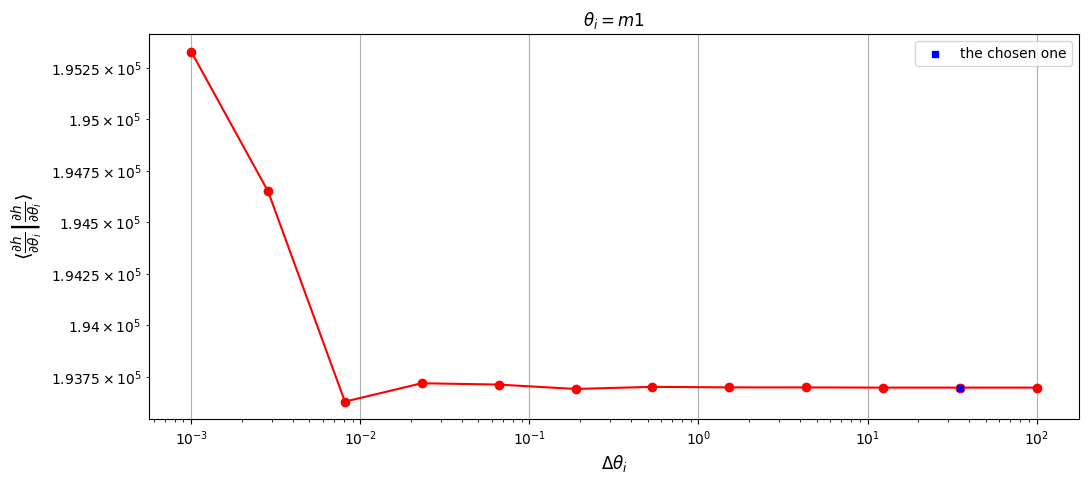

Gamma_ii for m2: 115012295616182.2
Gamma_ii for m2: 115012545415553.28
Gamma_ii for m2: 115012095773451.67
Gamma_ii for m2: 115011824336366.27
Gamma_ii for m2: 115015183086286.92
Gamma_ii for m2: 115020678654762.56
Gamma_ii for m2: 114996659644128.14
Gamma_ii for m2: 115048038405584.38
Gamma_ii for m2: 115063634613335.7
Gamma_ii for m2: 114847782568849.08
Gamma_ii for m2: 117336233948710.52
Gamma_ii for m2: 119004194247258.0
[np.float64(2.1719315069114566e-06), np.float64(3.909520112519906e-06), np.float64(2.3600798176403044e-06), np.float64(2.9202665513616945e-05), np.float64(4.777896061747045e-05), np.float64(0.0002088670289098116), np.float64(0.00044658528879133394), np.float64(0.00013554419520761903), np.float64(0.001879462011878425), np.float64(0.021207868159030724), np.float64(0.014015979092988282)]
0


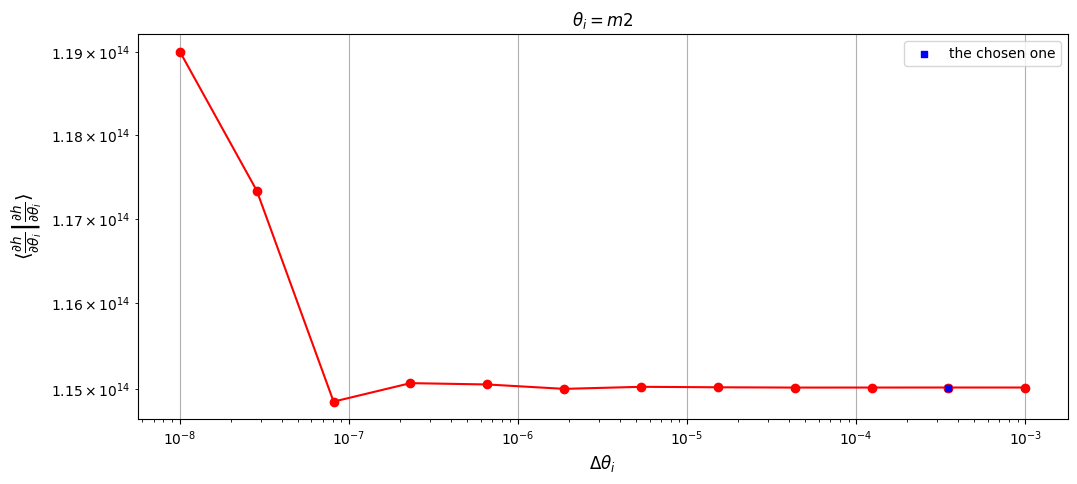

Gamma_ii for a: 7507889198875412.0
Gamma_ii for a: 7507890730714865.0
Gamma_ii for a: 7507844265654971.0
Gamma_ii for a: 7507670623459575.0
Gamma_ii for a: 7507940409785664.0
Gamma_ii for a: 7507072461201300.0
Gamma_ii for a: 7508441648551649.0
Gamma_ii for a: 7498444060173005.0
Gamma_ii for a: 7523600692348839.0
Gamma_ii for a: 7546466704965347.0
Gamma_ii for a: 7671036795836405.0
Gamma_ii for a: 7878559127145332.0
[np.float64(2.0403060033002713e-07), np.float64(6.188868368854808e-06), np.float64(2.3128637909794814e-05), np.float64(3.593346661853724e-05), np.float64(0.00011561745125677244), np.float64(0.00018235306531457312), np.float64(0.0013332883860192903), np.float64(0.003343695818601478), np.float64(0.003030028954008749), np.float64(0.016239016209473885), np.float64(0.02634013757590715)]
0


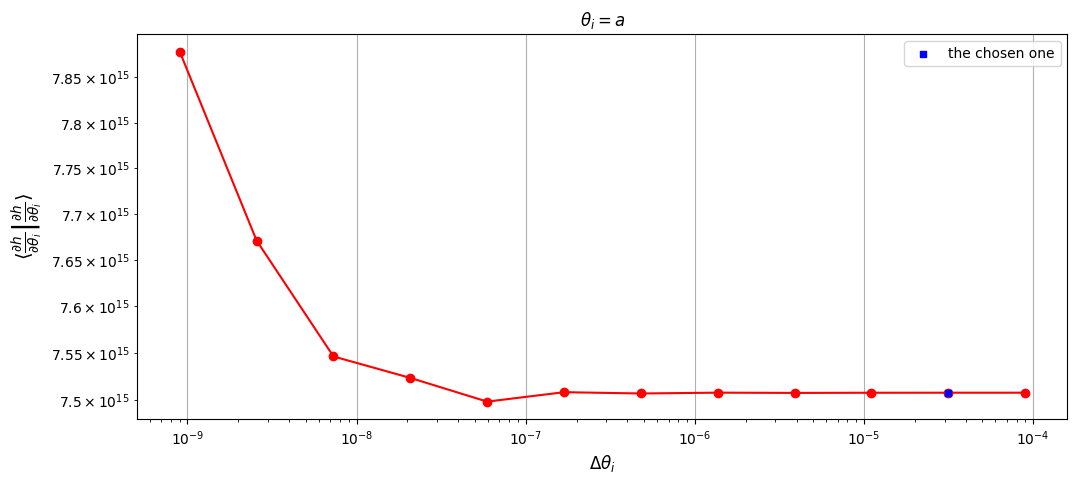

Gamma_ii for p0: 9130402998608238.0
Gamma_ii for p0: 9130408290610670.0
Gamma_ii for p0: 9130402783280730.0
Gamma_ii for p0: 9130418449105112.0
Gamma_ii for p0: 9130421544659888.0
Gamma_ii for p0: 9130440878295750.0
Gamma_ii for p0: 9131016579761074.0
Gamma_ii for p0: 9131369776167924.0
Gamma_ii for p0: 9128350775167372.0
Gamma_ii for p0: 9121062529347506.0
Gamma_ii for p0: 9120390330998698.0
Gamma_ii for p0: 9259396547887798.0
[np.float64(5.796019480795918e-07), np.float64(6.031858693117928e-07), np.float64(1.7157838350262505e-06), np.float64(3.3903744321755855e-07), np.float64(2.117492037866274e-06), np.float64(6.304900010805414e-05), np.float64(3.867945505523298e-05), np.float64(0.00033072797867987776), np.float64(0.0007990566665249449), np.float64(7.370280485949258e-05), np.float64(0.015012448831863598)]
3


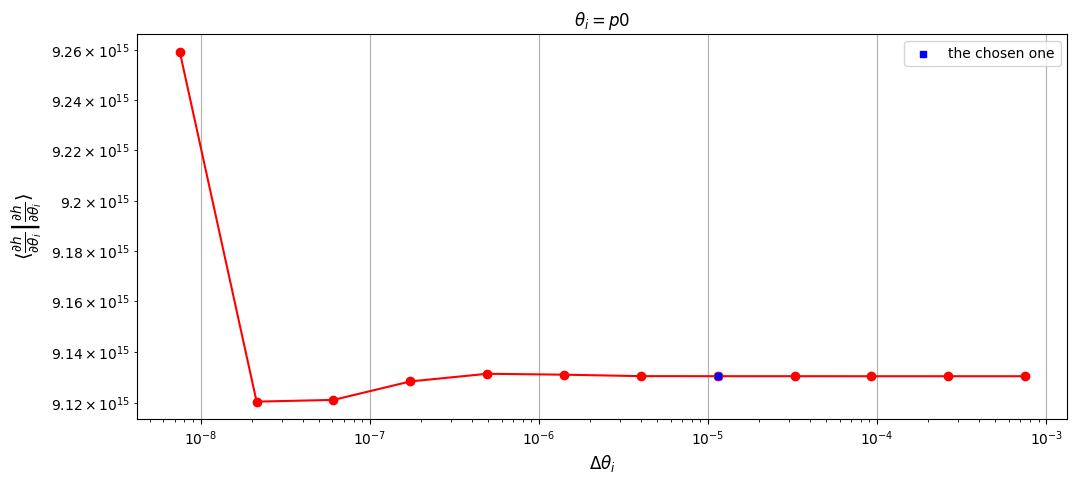

Gamma_ii for e0: 7.361237695295026e+16
Gamma_ii for e0: 7.361228183798149e+16
Gamma_ii for e0: 7.361222403147712e+16
Gamma_ii for e0: 7.361198880853418e+16
Gamma_ii for e0: 7.361296743732528e+16
Gamma_ii for e0: 7.361917246304266e+16
Gamma_ii for e0: 7.360510966562856e+16
Gamma_ii for e0: 7.36127235772509e+16
Gamma_ii for e0: 7.379776679367763e+16
Gamma_ii for e0: 7.325316551118174e+16
Gamma_ii for e0: 7.354964948509216e+16
Gamma_ii for e0: 7.305067320247272e+16
[np.float64(1.292107327651455e-06), np.float64(7.852840357503874e-07), np.float64(3.195443388383626e-06), np.float64(1.3294244549198659e-05), np.float64(8.428545866215715e-05), np.float64(0.00019105735291992802), np.float64(0.00010343200539708037), np.float64(0.002507436531840811), np.float64(0.007434508511618617), np.float64(0.004031072560998548), np.float64(0.006830550092761499)]
1


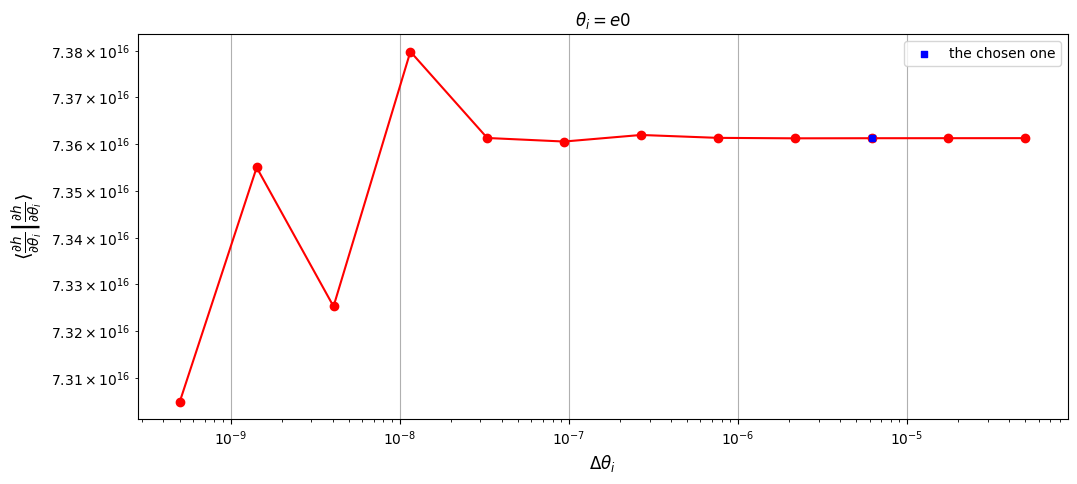

Gamma_ii for qS: 5902604.901072251
Gamma_ii for qS: 5130742.510921781
Gamma_ii for qS: 5706395.8760714475
Gamma_ii for qS: 5174667.382120594
Gamma_ii for qS: 2751957.230538983
Gamma_ii for qS: 6569957.808150773
Gamma_ii for qS: 5702957.555667558
Gamma_ii for qS: 5704789.813519798
Gamma_ii for qS: 5739976.157379957
Gamma_ii for qS: 5752689.793169527
Gamma_ii for qS: 5785870.222643785
Gamma_ii for qS: 5800474.765412456
[np.float64(0.15043873055555038), np.float64(0.10087862420543692), np.float64(0.10275607197248476), np.float64(0.880358940428414), np.float64(0.5811301516845557), np.float64(0.15202642559063), np.float64(0.0003211788535833857), np.float64(0.006130050525544289), np.float64(0.0022100332621213074), np.float64(0.005734734482014783), np.float64(0.0025178185164697786)]
6


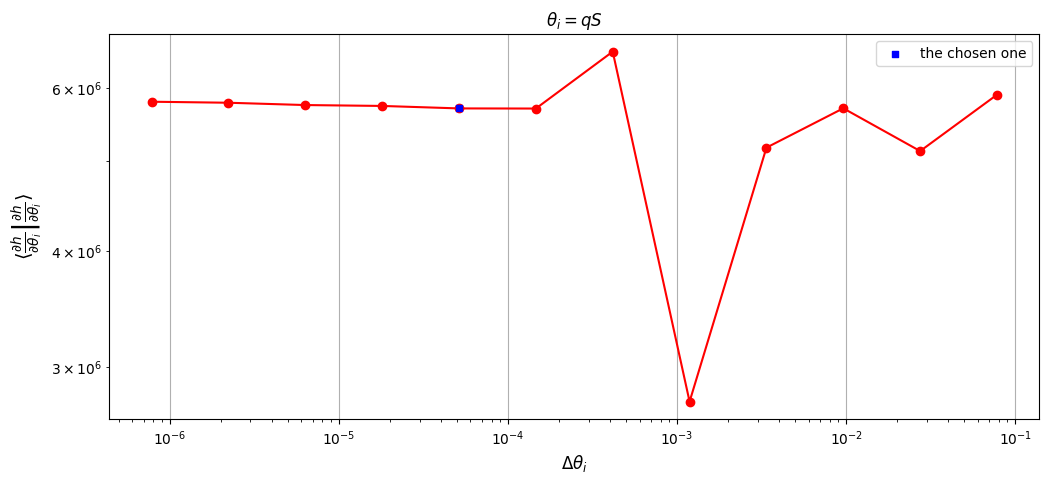

Gamma_ii for phiS: 17013553.51666976
Gamma_ii for phiS: 23065980.934161577
Gamma_ii for phiS: 23335118.647322603
Gamma_ii for phiS: 22766420.785093132
Gamma_ii for phiS: 23127374.446417436
Gamma_ii for phiS: 23129069.384884518
Gamma_ii for phiS: 23121068.208358906
Gamma_ii for phiS: 23125358.885410957
Gamma_ii for phiS: 23081097.149479322
Gamma_ii for phiS: 23204096.572285414
Gamma_ii for phiS: 23339928.133428942
Gamma_ii for phiS: 23356202.62286428
[np.float64(0.26239627244848474), np.float64(0.011533590946275527), np.float64(0.024979678079298216), np.float64(0.015607204447723956), np.float64(7.328174077722838e-05), np.float64(0.00034605566029681896), np.float64(0.0001855399119776549), np.float64(0.0019176616971448165), np.float64(0.005300763269232385), np.float64(0.005819707771464043), np.float64(0.000696795181054208)]
4


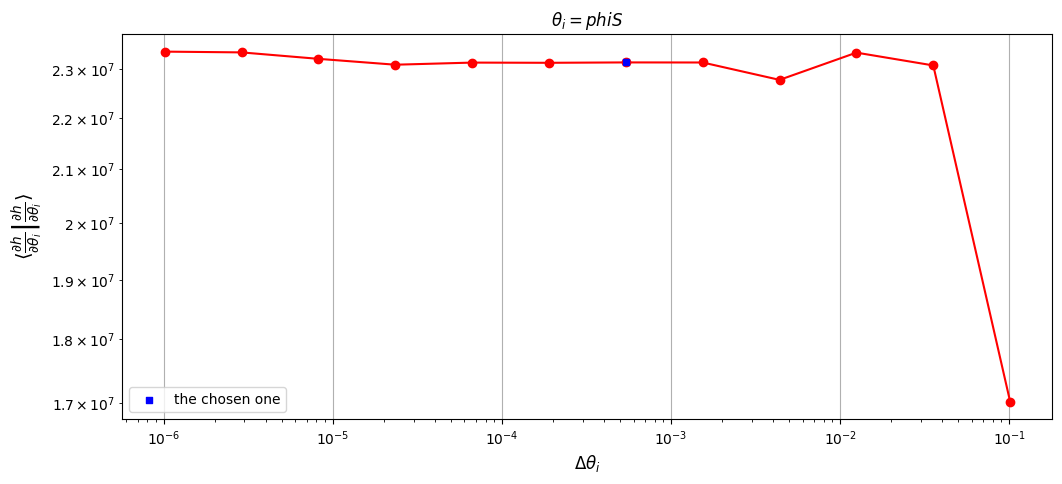

Gamma_ii for dev_1: 734643.023944885
Gamma_ii for dev_1: 734627.0582358517
Gamma_ii for dev_1: 734888.7054015538
Gamma_ii for dev_1: 734719.8320719834
Gamma_ii for dev_1: 732787.9960620588
Gamma_ii for dev_1: 737156.541278421
Gamma_ii for dev_1: 739532.3224612589
Gamma_ii for dev_1: 750980.2271663711
Gamma_ii for dev_1: 899376.0908258945
Gamma_ii for dev_1: 1122345.3780316194
Gamma_ii for dev_1: 1947820.1409988343
Gamma_ii for dev_1: 120107.47063525149
[np.float64(2.1733080553343808e-05), np.float64(0.0003560364498446143), np.float64(0.0002298472454379799), np.float64(0.0026362822812410376), np.float64(0.005926211017250035), np.float64(0.003212545429969848), np.float64(0.01524394956217145), np.float64(0.1649986753853462), np.float64(0.19866370153969062), np.float64(0.4237941407382279), np.float64(15.217310469505048)]
0


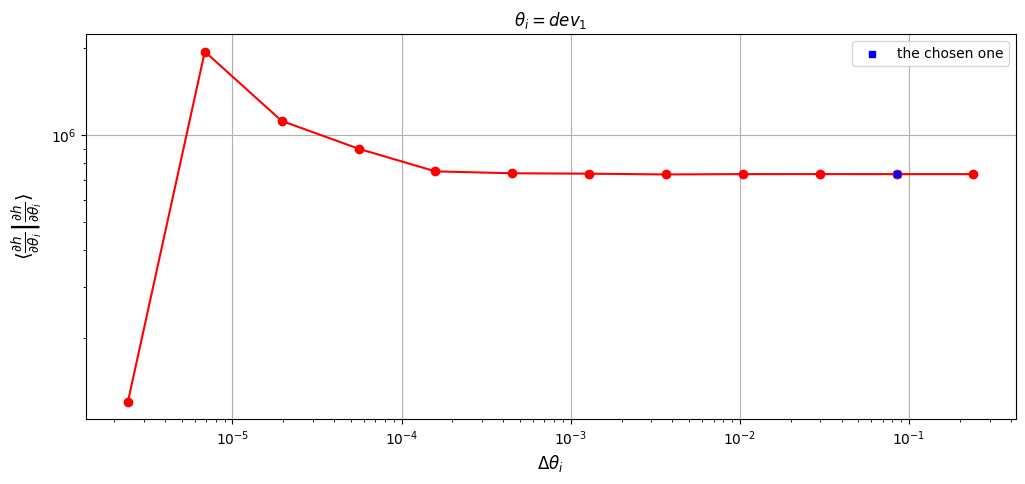

Gamma_ii for dev_2: 46356.586104181915
Gamma_ii for dev_2: 46334.74640781972
Gamma_ii for dev_2: 46408.08623412898
Gamma_ii for dev_2: 46448.04292604783
Gamma_ii for dev_2: 46154.96894180942
Gamma_ii for dev_2: 46810.65226500617
Gamma_ii for dev_2: 49537.990832688534
Gamma_ii for dev_2: 39230.53580012053
Gamma_ii for dev_2: 50721.749895334506
Gamma_ii for dev_2: 131795.5541431738
Gamma_ii for dev_2: 26753.609518214616
Gamma_ii for dev_2: 723848.6499201301
[np.float64(0.0004713459780262622), np.float64(0.0015803242982108908), np.float64(0.0008602448973460668), np.float64(0.0063497818535617236), np.float64(0.014007139218756627), np.float64(0.05505549421440572), np.float64(0.2627406132071317), np.float64(0.22655397573873848), np.float64(0.6151482481705428), np.float64(3.926271875704982), np.float64(0.9630397742384867)]
0


/home/svu/e1583490/packages_to_install/StableEMRIFisher/stableemrifisher/plot.py:163: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.scatter(
/home/svu/e1583490/bias_inference_emri/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


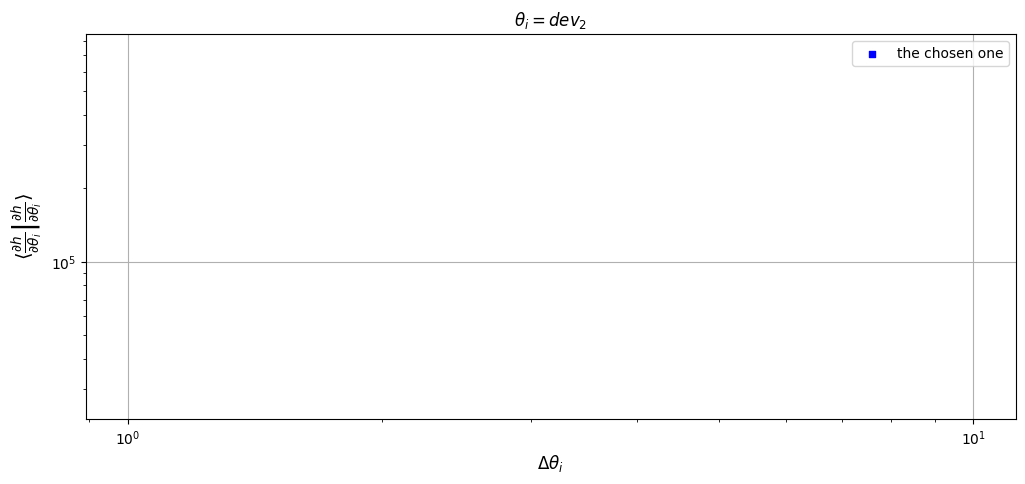

stable deltas: {'m1': 35.112227143289665, 'm2': 0.0003511041297945631, 'a': 3.1601564155071405e-05, 'p0': 1.1399163473758255e-05, 'e0': 6.164344585641473e-06, 'qS': 5.136922425161272e-05, 'phiS': 0.0005404874790949003, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev_1': 0.0845386256902597, 'dev_2': -0.09026982854381618}
Time taken to compute stable deltas is 39.65048813819885 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 3.4146556854248047 seconds


In [14]:
x_best_fit_0PA_dev = [1000008.8232475417, 9.999571552108547, 0.9000238821231858, 7.499888382688533,
                       0.500008994502528, 0.7807665326272081, 1.0127748551659106, 1.092204513244811,
                         0.3880586212252709, 2.4076903823412796, -2.5709170953033844]
add_kwargs_0PA_dev = {'chi2': 0.0, 'evolve_1PA': False, 'evolve_primary': False,
                      'evolve_2PA': False, 'deviation_included': True,
                      'dev_1': x_best_fit_0PA_dev[9], 'dev_2': x_best_fit_0PA_dev[10]}


m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_1,dev_2 = x_best_fit_0PA_dev
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs_0PA_dev['chi2'],add_kwargs_0PA_dev['evolve_1PA'],
                    add_kwargs_0PA_dev['evolve_primary'],add_kwargs_0PA_dev['evolve_2PA'],
                      add_kwargs_0PA_dev['deviation_included'],add_kwargs_0PA_dev['dev_1'],add_kwargs_0PA_dev['dev_2']]


param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0','dev_1','dev_2']  
dim = len(param_names_to_infer)
param_names = param_names_to_infer
SNR = sef.SNRcalc_SEF(*wave_params,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict = {
    'm1': wave_params[0],
    'm2': wave_params[1],
    'a': wave_params[2],
    'p0': wave_params[3],
    'e0': wave_params[4],
    'xI0': wave_params[5],
    'dist': wave_params[6],
    'qS': wave_params[7],
    'phiS': wave_params[8],
    'qK': wave_params[9],
    'phiK': wave_params[10],
    'Phi_phi0': wave_params[11],
    'Phi_theta0': wave_params[12],
    'Phi_r0': wave_params[13]}

Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_kwargs_0PA_dev,
            live_dangerously = False, stability_plot = True,der_order = 6, Ndelta = 12,return_derivatives = False)

Covariance_fit_0PA_dev = fishinv(m1, Fisher, index_of_M=0)

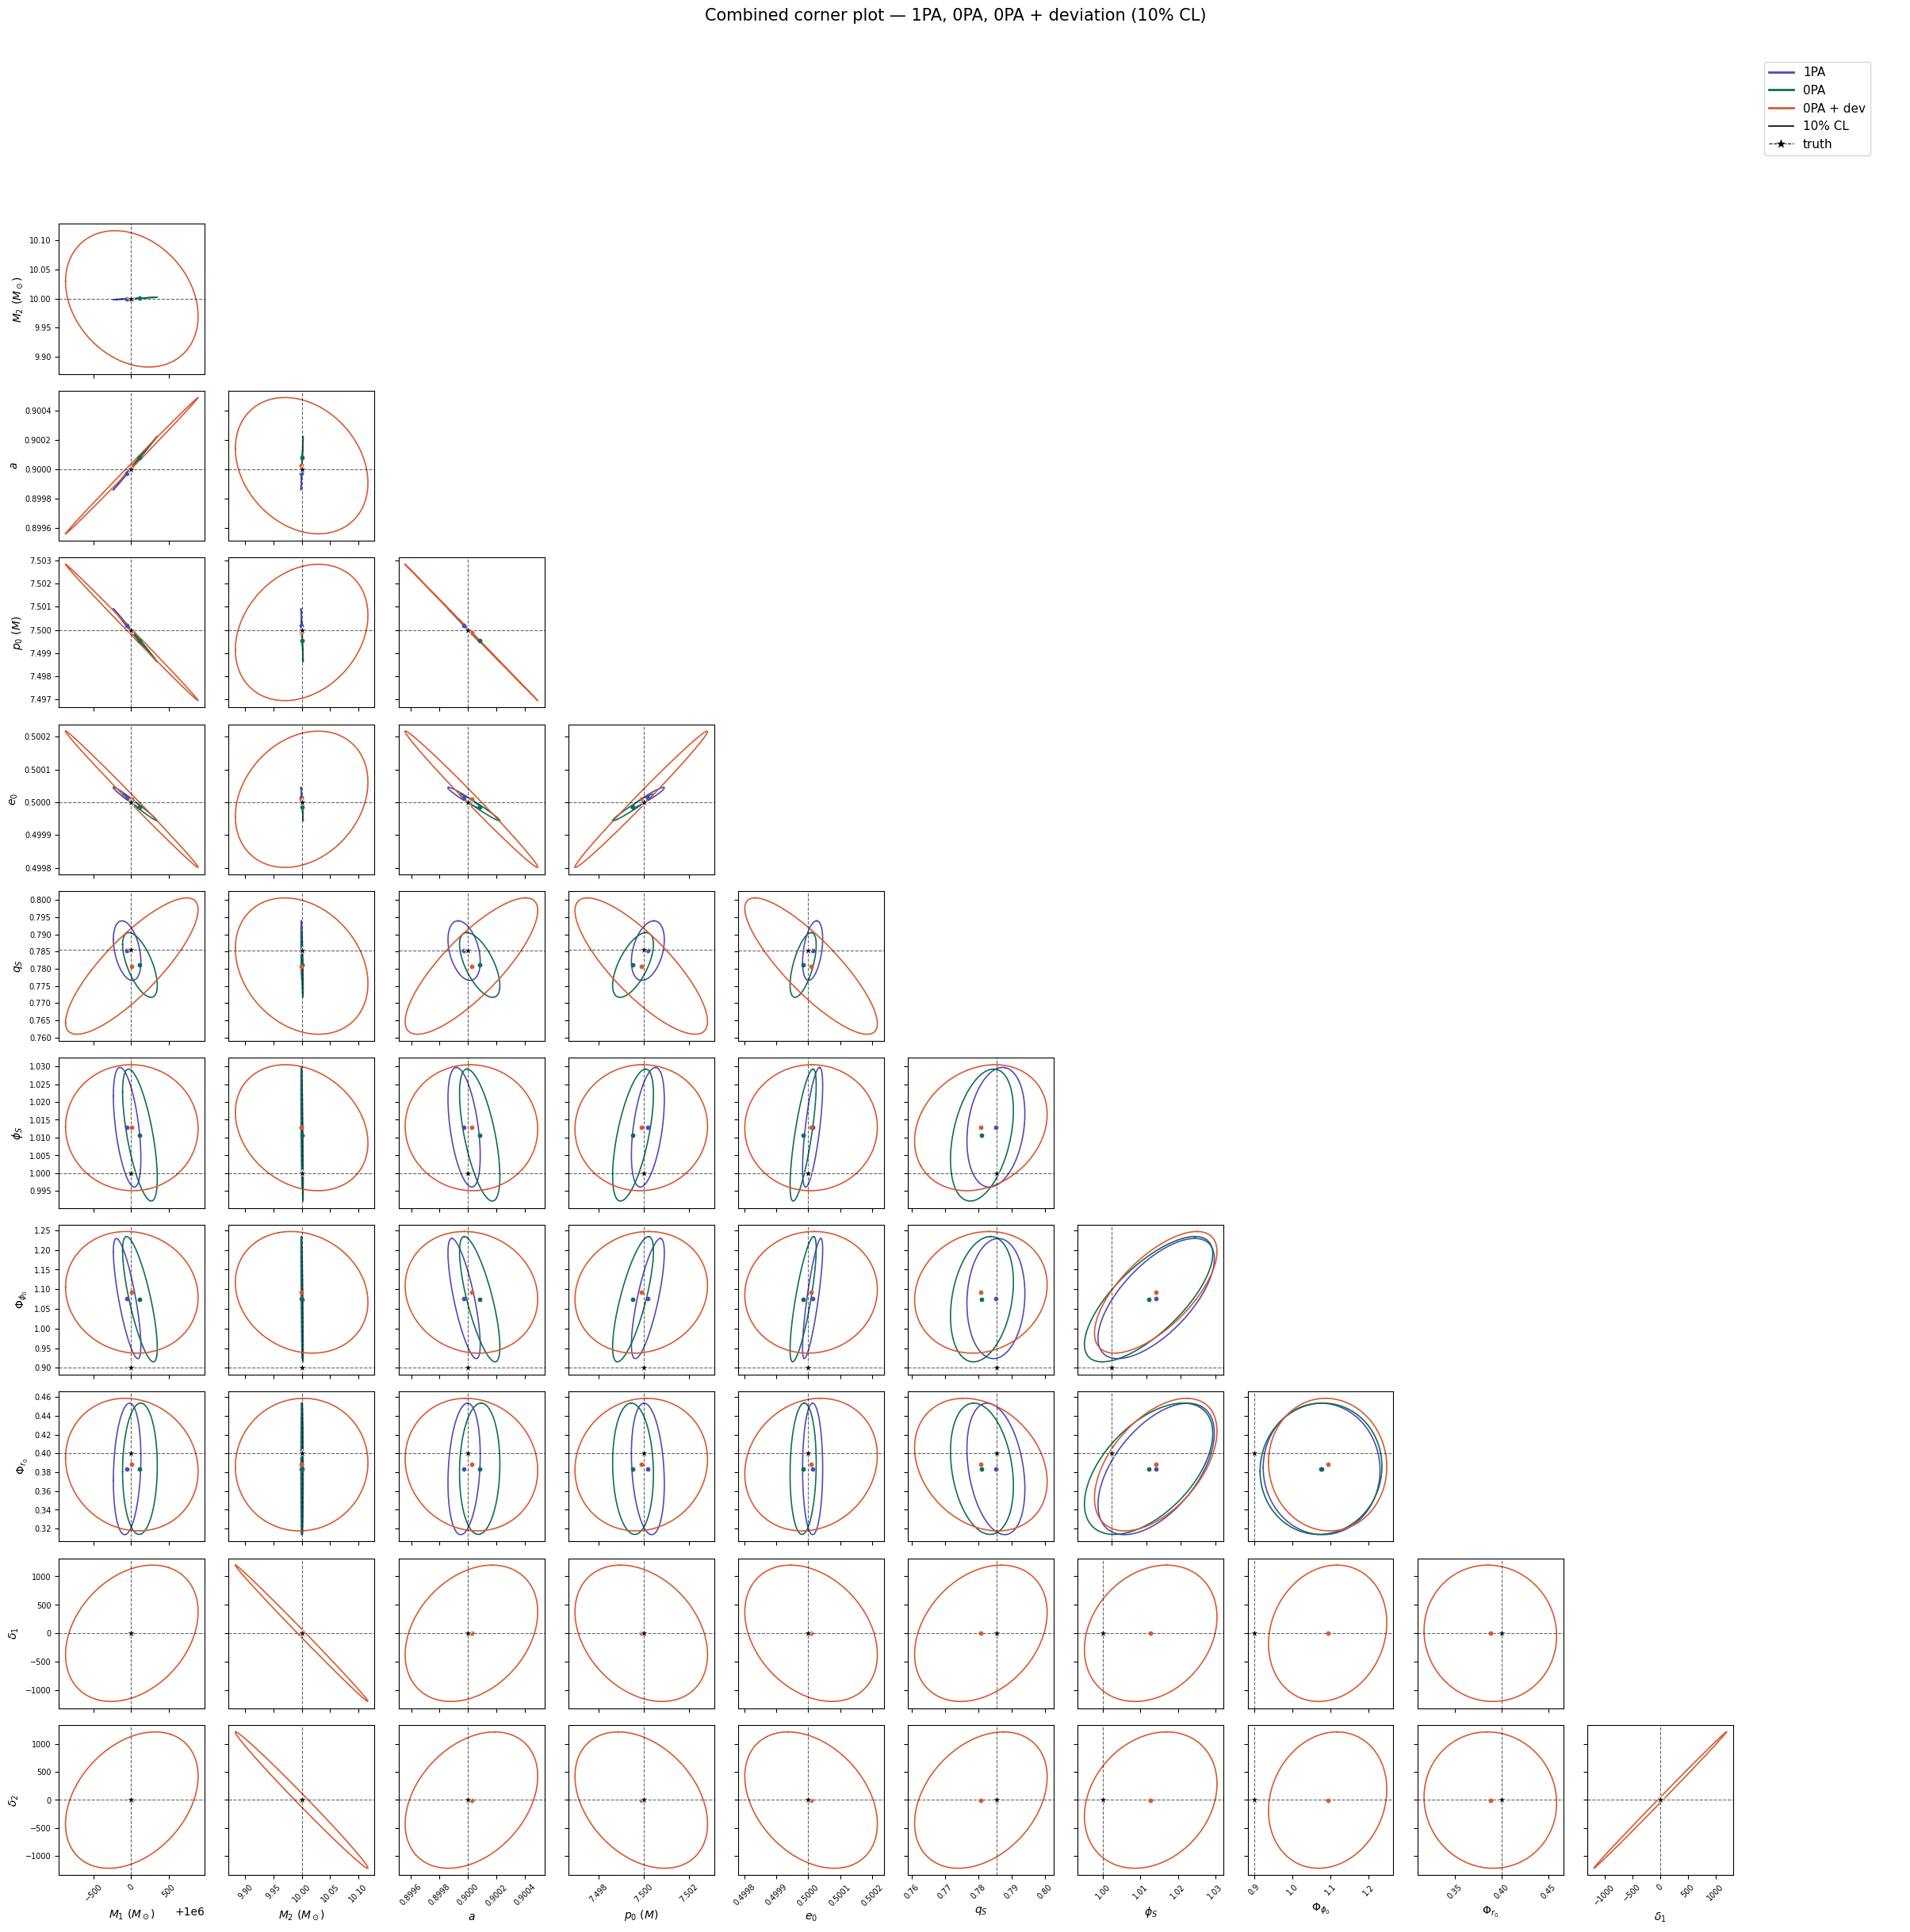

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# ── Best-fit values ───────────────────────────────────────────────────────────
x_best_fit_1PA = np.array([
    999946.0152291667, 9.999519502525063, 0.8999722828661775, 7.500180664516796,
    0.5000138337896617, 0.7852559788367258, 1.0129022856696843, 1.0763850352976,
    0.38346661248402214])

x_best_fit_0PA = np.array([
    1000117.1746453623, 10.000746537405398, 0.9000818185010706, 7.499523528259836,
    0.49998409810055455, 0.781083551558284, 1.0107113878780554, 1.074751977593931,
    0.38365434296900686])

x_best_fit_0PA_dev = np.array([1000008.8232475417, 9.999571552108547, 0.9000238821231858,
                       7.499888382688533, 0.500008994502528, 0.7807665326272081,
                         1.0127748551659106, 1.092204513244811, 0.3880586212252709,
                           2.4076903823412796, -2.5709170953033844])

# True injected parameters — order MUST match `labels` below.
signal_param = {"m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 5.0,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}
true_params = np.array([
    signal_param["m1"], signal_param["m2"], signal_param["a"],
    signal_param["p0"], signal_param["e0"],
    signal_param["qS"], signal_param["phiS"],
    signal_param["Phi_phi0"], signal_param["Phi_r0"],
    0.0, 0.0,            # dev_1, dev_2 — true injection (0 if no deviation)
])

labels = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
          r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$',
          r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
          r'$\delta_1$', r'$\delta_2$']

# ── Per-fit configuration ─────────────────────────────────────────────────────
fits = [
    ('1PA',       x_best_fit_1PA,     Covariance_fit_1PA,     '#534AB7', 9),
    ('0PA',       x_best_fit_0PA,     Covariance_fit_0PA,     '#0F6E56', 9),
    ('0PA + dev', x_best_fit_0PA_dev, Covariance_fit_0PA_dev, '#D85A30', 11),
]

LEVELS         = (0.40,)
LEVEL_STYLES   = {0.40: '-'}
N_PARAMS_TOTAL = 11
TRUTH_COLOR    = '#000000'


# ── Confidence-ellipse helper ─────────────────────────────────────────────────
def draw_ellipses(ax, mean, cov, i, j, color, levels, styles):
    cov2  = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]

    eigvals, eigvecs = np.linalg.eigh(cov2)
    order   = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    theta = np.linspace(0, 2 * np.pi, 400)
    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        ellipse = np.vstack([r1 * np.cos(theta), r2 * np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]
        ax.plot(ellipse[0], ellipse[1], color=color, lw=1.2, ls=styles[p])


# ── Combined corner plot ──────────────────────────────────────────────────────
def combined_triangle_plot():
    D = N_PARAMS_TOTAL
    fig, axes = plt.subplots(D, D, figsize=(2.2 * D, 2.2 * D))

    if len(true_params) != D:
        raise ValueError(
            f"true_params has {len(true_params)} entries; expected {D} to match labels.")

    for i in range(D):
        for j in range(D):
            ax = axes[i, j]

            if j >= i:
                ax.axis('off')
                continue

            for name, mean, cov, color, n in fits:
                if i >= n or j >= n:
                    continue
                draw_ellipses(ax, mean, cov, j, i, color, LEVELS, LEVEL_STYLES)
                ax.scatter(mean[j], mean[i], color=color, s=10, zorder=3)

            ax.axvline(true_params[j], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.axhline(true_params[i], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.scatter(true_params[j], true_params[i],
                       color=TRUTH_COLOR, marker='*', s=60, zorder=5,
                       edgecolor='white', linewidth=0.6)

            if i == D - 1:
                ax.set_xlabel(labels[j], fontsize=10)
                ax.tick_params(axis='x', labelrotation=45)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(labels[i], fontsize=10)
            else:
                ax.set_yticklabels([])

            ax.tick_params(labelsize=7)

    legend_handles = [plt.Line2D([0], [0], color=color, lw=2, label=name)
                      for name, _, _, color, _ in fits]
    legend_handles.append(plt.Line2D([0], [0], color='black', lw=1.2, ls='-',
                                     label='10% CL'))
    legend_handles.append(plt.Line2D([0], [0], color=TRUTH_COLOR, marker='*',
                                     ls='--', lw=0.8, markersize=10,
                                     markeredgecolor='white', markeredgewidth=0.6,
                                     label='truth'))

    fig.legend(handles=legend_handles, loc='upper right',
               bbox_to_anchor=(0.98, 0.98), fontsize=11, frameon=True)

    fig.suptitle('Combined corner plot — 1PA, 0PA, 0PA + deviation (10% CL)',
                 fontsize=15, y=1.005)
    plt.tight_layout()
    plt.show()


combined_triangle_plot()

In [16]:
np.save('Covariance_fit_1PA.npy',     Covariance_fit_1PA)
np.save('Covariance_fit_0PA.npy',     Covariance_fit_0PA)
np.save('Covariance_fit_0PA_dev.npy', Covariance_fit_0PA_dev)